In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB , BernoulliNB
from sklearn.metrics import (
     accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [7]:
train_data = fetch_20newsgroups (
    subset = "train",
    remove =("headers", "footer", "quotes")
)

In [8]:
test_data = fetch_20newsgroups (
    subset = "test",
    remove =("headers", "footer", "quotes")
)

In [51]:
x_train_text = train_data.data
y_train = train_data.target

x_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

print("Training document :" , len(x_train_text))
print("Testing document :" , len(x_test_text))
print("Number of classes :" , len(class_names))

vectorizer = CountVectorizer(
    stop_words = "english",
    min_df =2
)
x_train = vectorizer.fit_transform(x_train_text)
x_test = vectorizer.transform(x_test_text)
print("Training feature matrix:",x_train.shape)
print("Testining feature matrix:",x_test.shape)

Training document : 11314
Testing document : 7532
Number of classes : 20
Training feature matrix: (11314, 43934)
Testining feature matrix: (7532, 43934)


In [52]:
mnb=MultinomialNB()
mnb.fit(
    x_train,
    y_train
)
y_pred_mnb = mnb.predict(x_test)

In [54]:
binary_vectorizer = CountVectorizer(
stop_words="english",
min_df=2,
binary=True
)
x_train_binary = binary_vectorizer.fit_transform(
x_train_text
)
x_test_binary = binary_vectorizer.transform(
x_test_text
)

In [56]:
bnb = BernoulliNB()

bnb.fit(
x_train_binary,
y_train
)

y_pred_bnb = bnb.predict(
x_test_binary
)
results = pd.DataFrame({
    "Model": [
        "Multinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_mnb, average="macro"),
        precision_score(y_test, y_pred_bnb, average="macro")
    ],
    "Recall": [
        recall_score(y_test, y_pred_mnb, average="macro"),
        recall_score(y_test, y_pred_bnb, average="macro")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_mnb, average="macro"),
        f1_score(y_test, y_pred_bnb, average="macro")
    ]
})

print(results)

            Model  Accuracy  Precision    Recall  F1-Score
0  Multinomial NB  0.702602   0.680494  0.689438  0.670027
1    Bernoulli NB  0.547663   0.690536  0.531952  0.527454


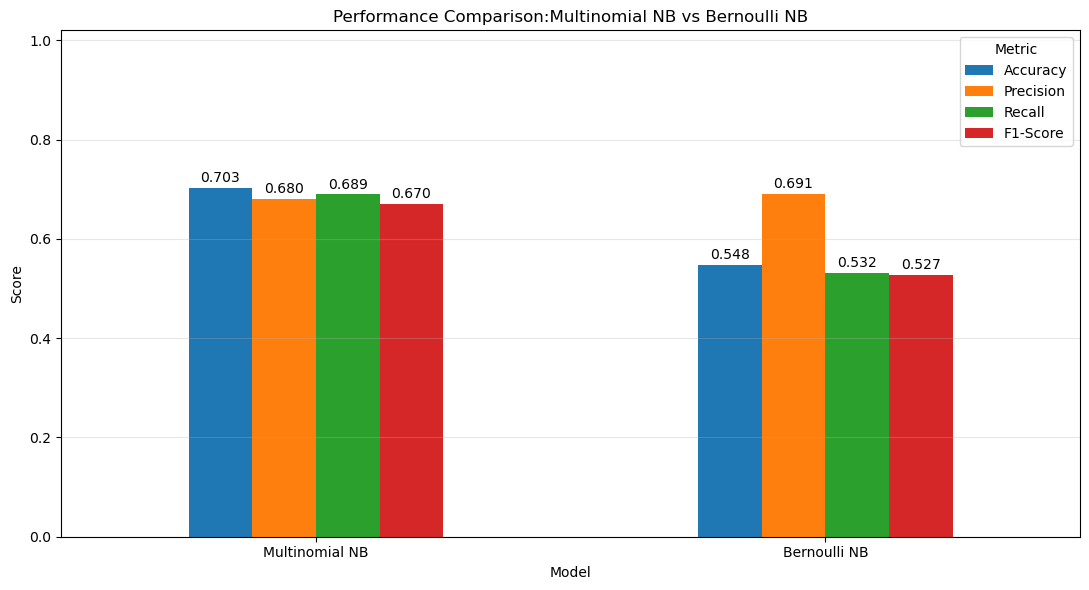

In [57]:
results_metrics = results[
    ["Model","Accuracy","Precision","Recall","F1-Score"]
]
ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title(
    "Performance Comparison:Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
   axis="y",
   alpha=0.3
)
for container in ax.containers:
 ax.bar_label(
   container,
   fmt="%.3f",
   padding=2
)
plt.tight_layout()
plt.show()